# Classification of Tree Species with Classic Machine Learning

## ENPC - ISDO - 2026
## Loic Landrieu

$\qquad\qquad\qquad\qquad\qquad\qquad\qquad\qquad$
<img src="https://drive.google.com/uc?id=1F4B80Q7XFcMK9aDKXGYRKgKw7q8sRP5i" alt="Cache la Poudre" width="300"/>

<center><em>Cache la Poudre Natural Reserve</em></center>

---

The objective of this practical session is to apply and compare several **classical supervised machine learning algorithms** for a real-world classification task: identifying tree species from environmental descriptors.

The dataset is composed of square forest parcels of size $30 \times 30\,\text{m}^2$.  
Each parcel must be classified into one of the following **seven tree species**:

> **Class index** | **Species**
> --- | ---
> 0 | Spruce / fir
> 1 | Lodgepole pine
> 2 | Ponderosa pine
> 3 | Cottonwood / willow
> 4 | Aspen poplar
> 5 | Douglas-fir
> 6 | Krummholz

For each parcel, we are given **14 handcrafted features**, designed by domain experts and derived from topographic and environmental measurements:

> **Index** | **Unit** | **Description**
> --- | --- | ---
> 0 | meter | Elevation
> 1 | degree | Aspect (azimuth)
> 2 | degree | Slope
> 3 | meter | Horizontal distance to nearest water body
> 4 | meter | Vertical distance to nearest water body
> 5 | meter | Horizontal distance to nearest road
> 6 | index (0–255) | Hillshade at 9am
> 7 | index (0–255) | Hillshade at 12pm
> 8 | index (0–255) | Hillshade at 3pm
> 9 | meter | Horizontal distance to nearest fire ignition point
> 10 | boolean | Rawah Wilderness Area
> 11 | boolean | Neota Wilderness Area
> 12 | boolean | Comanche Peak Wilderness Area
> 13 | boolean | Cache la Poudre Wilderness Area

All code sections that require your intervention are marked with `# TODO`.  
Make sure to complete **all** such sections before moving on.

You are strongly encouraged to:
- create additional cells to inspect variables,
- print tensor shapes,
- experiment with small code snippets.

Debugging is much easier when you verify intermediate results.

<font color='green'>
Q5 and Q8 ARE AT HOME QUESTION: SKIP DURING TP UNTIL YOU ARE FINISHED WITH THE GUIDED QUESTIONS. FOR THE TAKE HOME QUESTIONS, SEND TO YOUR TA:

- ENTIRE NOTEBOOK
- ANALYSIS FOR Q5 AND Q8 ONLY
- DO NOT SEND A DOCUMENT WILL ALL QUESTIONS CORRECTED IN CLASS, THIS IS NOT USEFUL FOR US.
</font>

---

## Installation and Data Loading




In [6]:
#import and installations
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn import datasets
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.datasets import fetch_openml
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.inspection import permutation_importance
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

**Q1**  
Execute the first cells to import to load and explore the dataset.  

In [7]:
class_names = ["Spruce", "Lodgepole pine", "Ponderosa pine", "Cottonwood", "Aspen poplar", "Douglas-fir", "Krummholz"]
feature_names = ["Elevation", "Azimuth", "Slope", "Hor dist to water", "Vert dist to water",
                 "distance to road", "Hillshade 9am", "Hillshade 12pm", "Hillshade 3pm",
                 "distance to fire", "Rawah Area", "Neota Area", "Comanche Peak Area", "Cache la Poudre Area"]

In [8]:
X, y = fetch_openml(
    name="covertype",
    version=3,
    as_frame=False,
    return_X_y=True
)

X, _, y, _ = train_test_split(#sample 50k plots for faster computation
    X, y,
    train_size=50000,
    random_state=42,
    stratify=y
)

# Convert labels from {1,...,7} to {0,...,6}
y = y.astype(int) - 1

# Keep only the first 14 features
X = X[:, :14].astype(np.float32)

Dataset summary
----------------
Number of samples      : 50000
Number of features     : 14
Feature vector shape   : (50000, 14)
Label vector shape     : (50000,)

Example feature vector (first sample):
------------------------------------
[0.430715 0.1      0.257576 0.021475 0.223514 0.183785 0.854331 0.791339
 0.448819 0.314373 1.       0.       0.       0.      ]


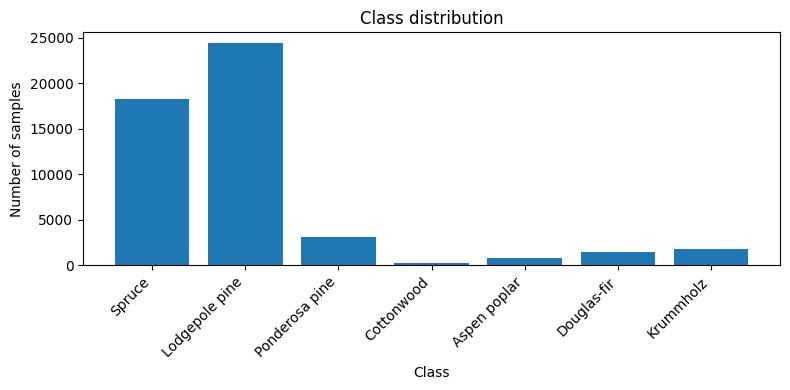


Label distribution:
-------------------------------------------
          Class name |    Count
-------------------------------------------
              Spruce |    18230
      Lodgepole pine |    24380
      Ponderosa pine |     3077
          Cottonwood |      236
        Aspen poplar |      817
         Douglas-fir |     1495
           Krummholz |     1765


In [9]:
# --------------------------------------------------
# Dataset summary
# --------------------------------------------------
print("Dataset summary")
print("----------------")
print(f"Number of samples      : {X.shape[0]}")
print(f"Number of features     : {X.shape[1]}")
print(f"Feature vector shape   : {X.shape}")
print(f"Label vector shape     : {y.shape}")

print("\nExample feature vector (first sample):")
print("------------------------------------")
print(X[0, :])

# --------------------------------------------------
# Label distribution (counts)
# --------------------------------------------------
K = int(y.max()) + 1
counts = np.bincount(y, minlength=K)

# Histogram
plt.figure(figsize=(8, 4))
plt.bar(
    range(K),
    counts,
    tick_label=class_names
)
plt.xlabel("Class")
plt.ylabel("Number of samples")
plt.title("Class distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# --------------------------------------------------
# Pretty table
# --------------------------------------------------
print("\nLabel distribution:")
print("-" * 43)
header_name = "Class name"
print(f"{header_name:>20} | {'Count':>8}")
print("-" * 43)

for k in range(K):
    name = class_names[k] if class_names is not None else str(k)
    print(f"{name:>20} | {counts[k]:>8}")


Q2) We split the dataset into three disjoint subsets:

- a training set used to fit model parameters (60\%),

- a validation set used to tune hyperparameters (20\%),

- a test set used only once for final evaluation (20\%).

Complete the code to split the data into a train+validation set and a test set (20%), then split the remaining data into a training set (60%) and a validation set (20%). Compute the prevalence (ratio) of each class in the train set. <font color='magenta'>What does "stratify" means here, and why is it important?</font>

In [10]:
# Train / validation / test split
#Stratify sert à avoir des répartitions représentative de nos données
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval,
    test_size=0.25,
    random_state=42,
    stratify=y_trainval
                                                 )

# Prevalence in training set
K = int(max(y_train.max(), y_test.max())) + 1
train_counts = np.bincount(y_train, minlength=K)
train_prevalence = np.zeros(7)
for arbre in y_test:
  train_prevalence[arbre]+=1/len(y_test)

print("Dataset split summary")
print("---------------------")
print(f"Training set   : {X_train.shape[0]:>7} samples")
print(f"Validation set : {X_val.shape[0]:>7} samples")
print(f"Test set       : {X_test.shape[0]:>7} samples")

print("\nTotal samples  :", X.shape[0])

assert X_train.shape[0] + X_val.shape[0] + X_test.shape[0] == X.shape[0]
assert X_train.shape[1] == X_val.shape[1] == X_test.shape[1]
assert len(y_train) == X_train.shape[0]

Dataset split summary
---------------------
Training set   :   30000 samples
Validation set :   10000 samples
Test set       :   10000 samples

Total samples  : 50000


## Q3 — Logistic Regression (Baseline)

We start with **multinomial logistic regression**, a strong baseline for tabular classification.

### Q3.1 — Complete the code to train the regression model.
<font color='magenta'>Why do we normalise the input?</font>

### Q3.2 — Evaluate the model
Compute the accuracy and per-class F1 on the **test set**, and visualise the confusion matrix. <font color='magenta'> How are rare classes classified? Is rarity the only factor for difficulty? </font>

In [11]:
# Q3.1
clf = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=250,
        n_jobs=-1
    )
)

clf.fit(X_train,y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('logisticregression',
                 LogisticRegression(max_iter=250, n_jobs=-1))])

In [12]:
# Q3.2
def eval_clf(clf, X_test, y_test, silent=False):
    y_test_pred = clf.predict(X_test)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Macro F1
    f1 = f1_score(y_test,y_test_pred, average='macro')
    if not silent:
      print("Performance")
      print("----------------")
      print(f"Macro F1: {100*f1:.2f}%")
      print(f"Overall accuracy: {100*test_acc:.2f}%")

      # Per-class F1 (test)
      f1_per_class = f1_score(y_test, y_test_pred, average=None)

      print("\nPer-class F1 (test) and training prevalence")
      print("-" * 43)
      header_name = "Class name" if class_names is not None else "Class"
      print(f"{header_name:>20} | {'F1 (test)':>9} | {'Train %':>8}")
      print("-" * 43)

      for k in range(K):
          name = class_names[k] if class_names is not None else str(k)
          print(f"{name:>20} | {100*f1_per_class[k]:>8.2f}% | {100*train_prevalence[k]:>7.2f}%")

    return f1

f1 = eval_clf(clf,X_test,y_test)

Performance
----------------
Macro F1: 45.85%
Overall accuracy: 70.89%

Per-class F1 (test) and training prevalence
-------------------------------------------
          Class name | F1 (test) |  Train %
-------------------------------------------
              Spruce |    69.84% |   36.46%
      Lodgepole pine |    76.55% |   48.76%
      Ponderosa pine |    68.81% |    6.16%
          Cottonwood |    36.11% |    0.47%
        Aspen poplar |     0.00% |    1.63%
         Douglas-fir |    22.94% |    2.99%
           Krummholz |    46.72% |    3.53%


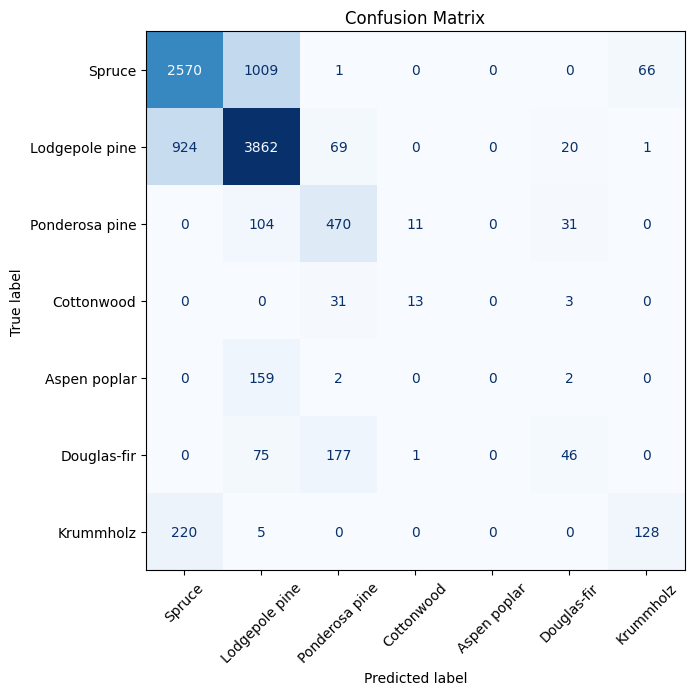

In [13]:
# Q3.2
cm = confusion_matrix(y_test,clf.predict(X_test))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

## Q4 — Feature Importance (Logistic Regression)

We now analyse which features the logistic regression relies on.

### Q4.1 — Coefficient magnitude baseline
A simple baseline is to rank features by the sum of absolute coefficients across classes:
$$
\text{score}(j) = \sum_{k=1}^{K} |w_{k,j}|.
$$
<font color='magenta'>Why is this only meaningful after normalization?</font>

### Q4.2 — Permutation importance
A stronger, model-agnostic approach is **permutation importance**:
we randomly permute one feature column (destroying its information) and measure the performance drop.

### Q4.3 — Reduced-feature model
Retrain the classifier using only the **top-5 most important features** and compare performance. <font color='magenta'>Is this useful? Why or why not?</font>

### Q4.4 — Intercept analysis
Inspect the intercept vector. <font color='magenta'>What does it tell you about class prevalence / baseline bias?
</font>

In [14]:
#Q4.1
logreg = clf.named_steps["logisticregression"]
coef = logreg.coef_
intercept = logreg.intercept_

print("Logistic regression parameters")
print("------------------------------")
print("Coefficient matrix shape:", coef)
print("Intercept shape:", intercept)

# Baseline importance: sum of abs coefficients across classes
feat_score_L1 = np.zeros(14)
for j in range(14):
  for i in range (7):
    feat_score_L1[j]+=abs(coef[i][j])

order=np.argsort(-feat_score_L1)


print("\nFeature ranking by sum_k |coef[k, j]|")
print("-------------------------------------")
for idx in order:
    print(f"{feature_names[idx]:>35} : score = {feat_score_L1[idx]:.4f}")


Logistic regression parameters
------------------------------
Coefficient matrix shape: [[ 3.53829564e+00 -2.00948050e-01 -1.65146734e-01 -2.19619068e-01
  -3.14041896e-01 -4.67671968e-01 -3.75454730e-01 -6.29986284e-01
   3.37277871e-01 -3.11583917e-01  9.78601734e-01  3.16926027e-02
  -5.97866422e-01 -8.10205271e-01]
 [ 1.02369752e+00 -1.74177230e-01  4.81058061e-02  2.92565868e-01
  -2.13683711e-01 -2.73275382e-01 -3.54175088e-01  1.70084939e-02
   7.11046734e-02 -3.42983011e-01  7.95363079e-01  1.35868667e-01
  -7.33495511e-01 -2.55097523e-01]
 [-3.88237778e+00  1.61230047e-01  1.29885385e-01  9.90024243e-01
   5.80967181e-02 -2.29120825e-02 -1.00454383e+00  1.20164560e+00
  -1.48852365e+00 -4.04645071e-01 -1.41005114e+00 -5.46260079e-02
   1.19006380e+00  5.06034985e-01]
 [-5.44525449e+00  2.43728259e-01  3.53804975e-03 -1.03735958e+00
   8.72181966e-01  2.17196843e+00  7.04438604e-01  1.10415780e+00
  -7.58748316e-01  1.58240005e+00 -6.11454562e-01  1.04508190e+00
  -5.94474975e-

In [15]:
#Q4.2
result = permutation_importance(
    clf,X_val,y_val,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)



imp = result.importances_mean
imp_std = result.importances_std
order_perm = np.argsort(-imp)
print("Permutation importance (validation)")
print("-"*50)
for idx in order_perm:
    print(f"{feature_names[idx]:>20} : {imp[idx]:.6f} ± {imp_std[idx]:.6f}")


Permutation importance (validation)
--------------------------------------------------
           Elevation : 0.287200 ± 0.005041
      Hillshade 12pm : 0.053020 ± 0.003229
       Hillshade 3pm : 0.045000 ± 0.001545
   Hor dist to water : 0.025980 ± 0.001238
       Hillshade 9am : 0.025940 ± 0.001145
Cache la Poudre Area : 0.024120 ± 0.001564
          Rawah Area : 0.020700 ± 0.001644
    distance to road : 0.013800 ± 0.002390
    distance to fire : 0.007520 ± 0.000578
  Comanche Peak Area : 0.006580 ± 0.000531
               Slope : 0.005320 ± 0.001383
  Vert dist to water : 0.003100 ± 0.000982
          Neota Area : 0.002960 ± 0.000739
             Azimuth : -0.000020 ± 0.000673


Top-5 selected features:
 - Elevation
 - Hillshade 12pm
 - Hillshade 3pm
 - Hor dist to water
 - Hillshade 9am
Performance
----------------
Macro F1: 41.73%
Overall accuracy: 69.90%

Per-class F1 (test) and training prevalence
-------------------------------------------
          Class name | F1 (test) |  Train %
-------------------------------------------
              Spruce |    69.04% |   36.46%
      Lodgepole pine |    76.05% |   48.76%
      Ponderosa pine |    66.46% |    6.16%
          Cottonwood |    25.40% |    0.47%
        Aspen poplar |     0.00% |    1.63%
         Douglas-fir |    22.11% |    2.99%
           Krummholz |    33.07% |    3.53%


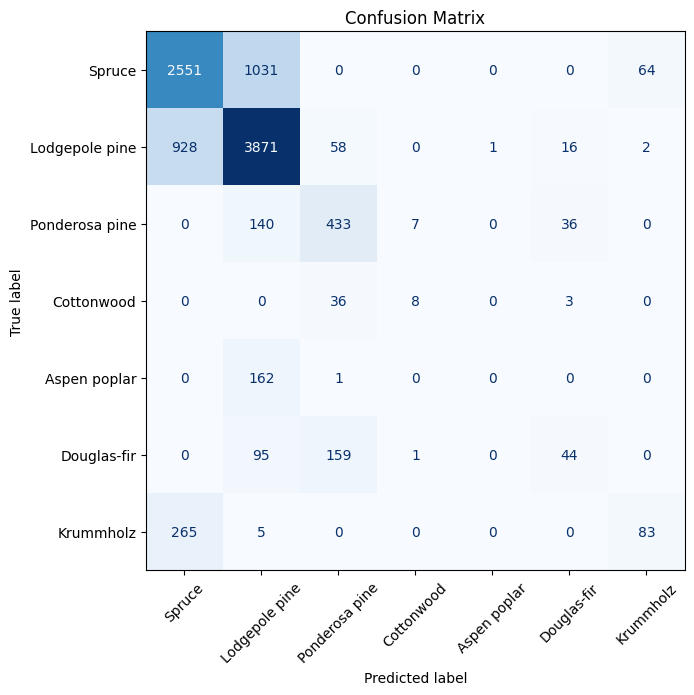

In [16]:
#Q4.3
top5_idx =order_perm[:5]
top5_names = [feature_names[i] for i in top5_idx]

print("Top-5 selected features:")
for name in top5_names:
    print(" -", name)

# Slice data
X_train_top5 = X_train[:,top5_idx]
X_test_top5  =X_test[:,top5_idx]

clf_top5 = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=250,
        n_jobs=-1
    ))


clf_top5.fit(X_train_top5,y_train)

f1 = eval_clf(clf_top5,X_test_top5,y_test)



cm = confusion_matrix(y_test,clf_top5.predict(X_test_top5))
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, cmap="Blues", colorbar=False, xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [17]:
#Q4.4
print("Intercept analysis (multinomial logits)")
print("-" * 50)

header_name = "Class name" if "class_names" in globals() else "Class"
print(f"{header_name:>20} | {'Intercept':>10} | {'Train %':>8}")
print("-" * 50)

for k in range(K):
    name = class_names[k] if "class_names" in globals() else str(k)
    print(" Class Name:" , name, '| ' "Value of intercept:", intercept[k], '| ' "Train prevalence" , train_prevalence[k])

Intercept analysis (multinomial logits)
--------------------------------------------------
          Class name |  Intercept |  Train %
--------------------------------------------------
 Class Name: Spruce | Value of intercept: 6.486099461057865 | Train prevalence 0.36459999999997617
 Class Name: Lodgepole pine | Value of intercept: 7.5397405753095725 | Train prevalence 0.4875999999999626
 Class Name: Ponderosa pine | Value of intercept: -2.9441510822702988 | Train prevalence 0.06160000000000074
 Class Name: Cottonwood | Value of intercept: -10.400650478612816 | Train prevalence 0.004699999999999999
 Class Name: Aspen poplar | Value of intercept: 2.7472535887799236 | Train prevalence 0.016299999999999957
 Class Name: Douglas-fir | Value of intercept: -2.7736734223068096 | Train prevalence 0.029899999999999875
 Class Name: Krummholz | Value of intercept: -0.6546186419576743 | Train prevalence 0.035299999999999984


### Q5 — Ridge Regularisation for Logistic Regression
<font color='green'>
AT HOME QUESTION: SKIP DURING TP UNTIL YOU ARE FINISHED WITH THE GUIDED QUESTIONS
</font>

In this question, you will tune the regularisation strength of logistic regression using the validation set, then report the final performance on the test set.

Recall that in scikit-learn’s LogisticRegression, L2 (ridge) regularisation is controlled by the parameter C, where:
 - smaller C → stronger regularisation
 - larger C → weaker regularisation

Q5.1 — Model selection on the validation set

Train several L2-regularised logistic regression models for a range of C values.
For each model:

- train on the training set,

- evaluate on the validation set using macro-F1,

Select the C that maximises validation macro-F1.

Q5.2 — Final evaluation on the test set

Retrain the model on train + validation using the best C, and evaluate once on the test set.

Performance
----------------
Macro F1: 45.85%
Overall accuracy: 70.89%

Per-class F1 (test) and training prevalence
-------------------------------------------
          Class name | F1 (test) |  Train %
-------------------------------------------
              Spruce |    69.84% |   36.46%
      Lodgepole pine |    76.55% |   48.76%
      Ponderosa pine |    68.81% |    6.16%
          Cottonwood |    36.11% |    0.47%
        Aspen poplar |     0.00% |    1.63%
         Douglas-fir |    22.94% |    2.99%
           Krummholz |    46.72% |    3.53%


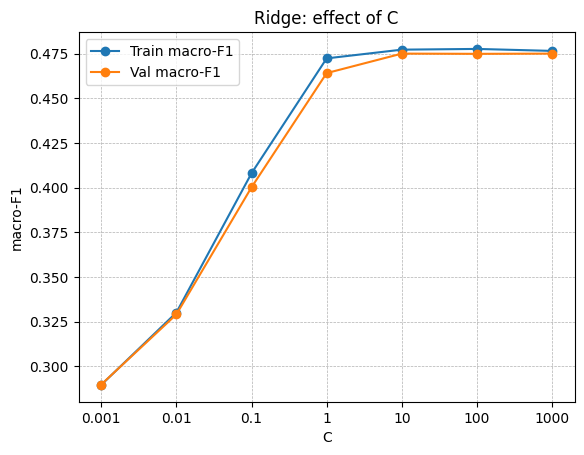

In [18]:
#5.1
clf_ridge = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=1,
        max_iter=250,
        n_jobs=-1
    )
)

clf_ridge.fit(X_train,y_train)

eval_clf(clf_ridge,X_test,y_test)


C_grid = [0.001, 0.01, 0.1, 1, 10, 100, 1000] #
train_scores = []
val_scores = []

for c_val in C_grid:
    clf_ridge_d = make_pipeline(
        StandardScaler(),
        LogisticRegression(
            C=c_val,
            max_iter=250,
            n_jobs=-1
        )
    )
    clf_ridge_d.fit(X_train,y_train)

    y_tr_pred = clf_ridge_d.predict(X_train)
    y_va_pred = clf_ridge_d.predict(X_val)

    train_scores.append(f1_score(y_train,y_tr_pred,average='macro'))
    val_scores.append(f1_score(y_val,y_va_pred,average='macro'))

plt.figure()
x = list(range(len(C_grid)))
plt.plot(x, train_scores, marker="o", label="Train macro-F1")
plt.plot(x, val_scores, marker="o", label="Val macro-F1")
plt.xticks(x, [str(c) for c in C_grid])
plt.xlabel("C")
plt.ylabel("macro-F1")
plt.title("Ridge: effect of C")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

In [19]:
# Q5.2

best_c_idx = np.argmax(val_scores)
best_C = C_grid[best_c_idx]

print(f"Best C from validation: {best_C}")

clf_final = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        C=best_C,
        max_iter=250,
        n_jobs=-1
    )
)

X_train_full = np.concatenate((X_train, X_val), axis=0)
y_train_full = np.concatenate((y_train, y_val), axis=0)

clf_final.fit(X_train_full, y_train_full)

print("\nFinal evaluation on the test set with best C:")
f1_final = eval_clf(clf_final, X_test, y_test)


Best C from validation: 10

Final evaluation on the test set with best C:
Performance
----------------
Macro F1: 47.71%
Overall accuracy: 71.05%

Per-class F1 (test) and training prevalence
-------------------------------------------
          Class name | F1 (test) |  Train %
-------------------------------------------
              Spruce |    69.85% |   36.46%
      Lodgepole pine |    76.66% |   48.76%
      Ponderosa pine |    69.27% |    6.16%
          Cottonwood |    45.33% |    0.47%
        Aspen poplar |     0.00% |    1.63%
         Douglas-fir |    23.84% |    2.99%
           Krummholz |    49.03% |    3.53%


## Q6 — A Single Decision Tree (CART)

We now move from linear models to **decision trees**.  
A decision tree partitions the feature space using a sequence of axis-aligned splits, leading to a piecewise-constant prediction rule.

### Q6.1 — Train a single decision tree
Train a decision tree classifier on the training set.  
Evaluate it on both the training and validation sets.
<font color='magenta'>How does this model compare to logistic regression? Why?
</font>

### Q6.2 — Visualise the tree structure (small depth)
To make the model interpretable, train a shallow tree (e.g. `max_depth=3`) and visualise it:
<font color='magenta'>
- Which features appear near the root?
- What does it mean when a feature is used near the top?
</font>

### Q6.3 — Overfitting check
Train a deeper tree (e.g. `max_depth=None` or a large value) and compare train vs validation metrics.
<font color='magenta'>
- What do you observe?
- Is the tree overfitting?
</font>

In [20]:
#Q6.1
tree = DecisionTreeClassifier(
    random_state=42
)
tree.fit(X_train,y_train)

f1 = eval_clf(tree,X_test,y_test)

Performance
----------------
Macro F1: 68.32%
Overall accuracy: 78.51%

Per-class F1 (test) and training prevalence
-------------------------------------------
          Class name | F1 (test) |  Train %
-------------------------------------------
              Spruce |    78.03% |   36.46%
      Lodgepole pine |    82.04% |   48.76%
      Ponderosa pine |    73.68% |    6.16%
          Cottonwood |    59.34% |    0.47%
        Aspen poplar |    51.63% |    1.63%
         Douglas-fir |    58.95% |    2.99%
           Krummholz |    74.57% |    3.53%


Performance
----------------
Macro F1: 35.73%
Overall accuracy: 67.27%

Per-class F1 (test) and training prevalence
-------------------------------------------
          Class name | F1 (test) |  Train %
-------------------------------------------
              Spruce |    63.38% |   36.46%
      Lodgepole pine |    74.68% |   48.76%
      Ponderosa pine |    62.87% |    6.16%
          Cottonwood |     0.00% |    0.47%
        Aspen poplar |     0.00% |    1.63%
         Douglas-fir |     0.00% |    2.99%
           Krummholz |    49.20% |    3.53%


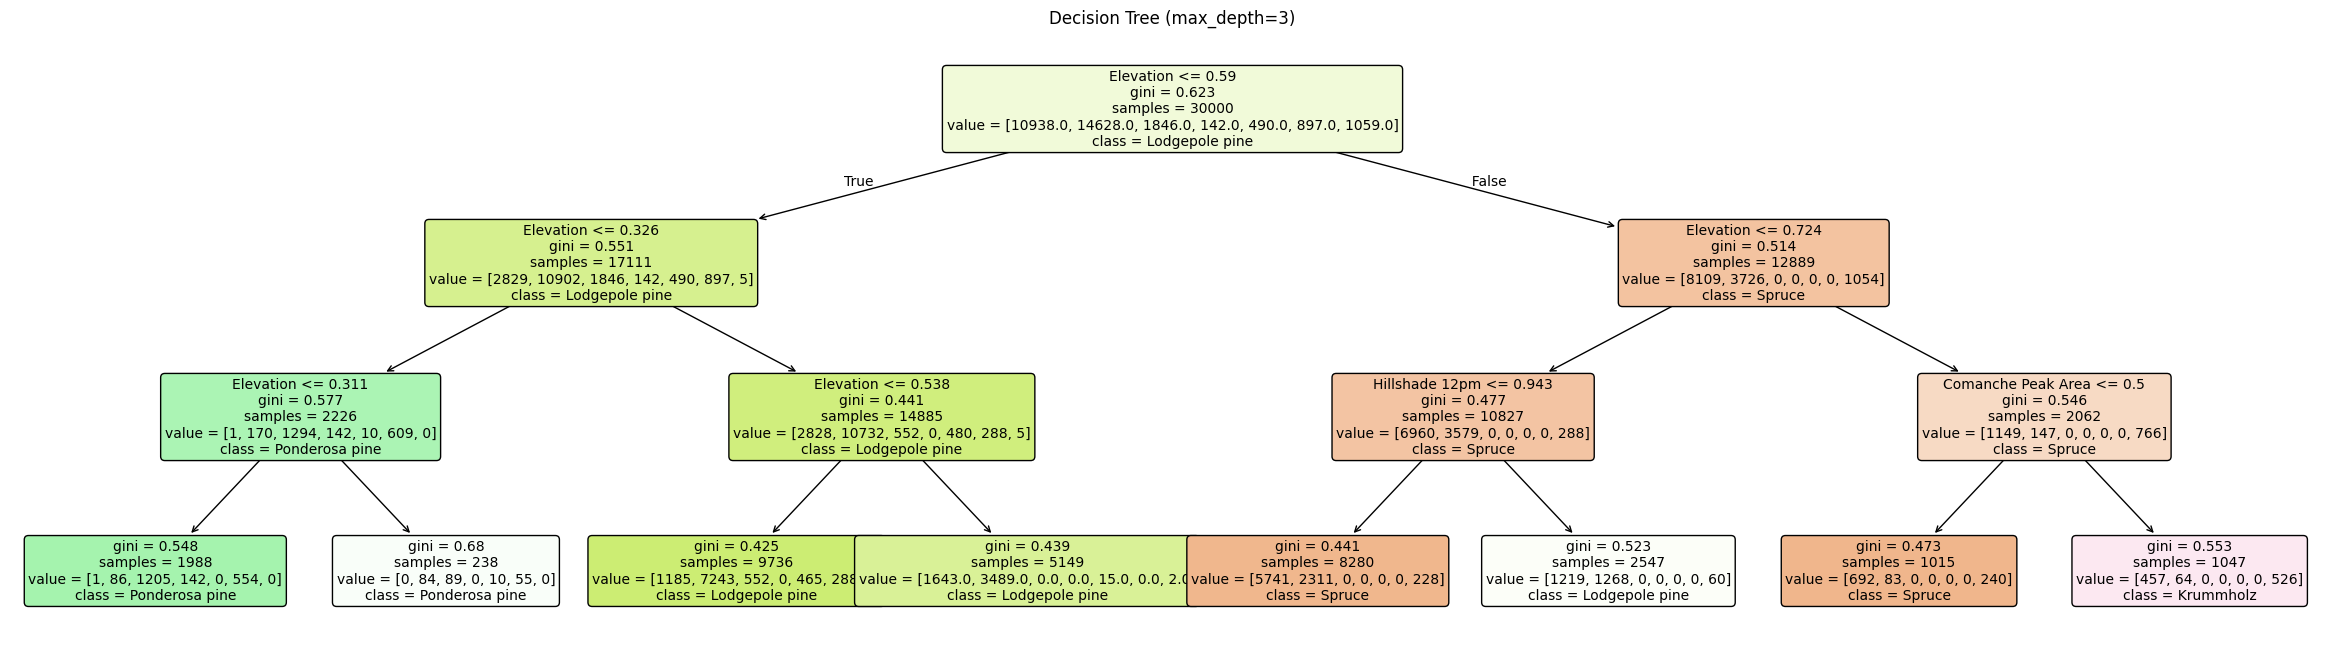

In [21]:
#Q6.2
tree_small =  DecisionTreeClassifier(
    random_state=42,
    max_depth=3
)

tree_small.fit(X_train,y_train)

f1 = eval_clf(tree_small,X_test,y_test)

plt.figure(figsize=(30, 8))
plot_tree(
    tree_small,
    feature_names=(feature_names if "feature_names" in globals() else None),
    class_names=(class_names if "class_names" in globals() else None),
    filled=True,
    rounded=True,
    impurity=True,
    fontsize=10
)
plt.title("Decision Tree (max_depth=3)")
plt.show()

In [22]:
#Q6.3
tree_deep =DecisionTreeClassifier(
    random_state=42,
    max_depth=None
)
tree_deep.fit(X_train,y_train)

f1_train = eval_clf(tree_deep,X_train,y_train)

f1_test = eval_clf(tree_deep,X_test,y_test)

Performance
----------------
Macro F1: 100.00%
Overall accuracy: 100.00%

Per-class F1 (test) and training prevalence
-------------------------------------------
          Class name | F1 (test) |  Train %
-------------------------------------------
              Spruce |   100.00% |   36.46%
      Lodgepole pine |   100.00% |   48.76%
      Ponderosa pine |   100.00% |    6.16%
          Cottonwood |   100.00% |    0.47%
        Aspen poplar |   100.00% |    1.63%
         Douglas-fir |   100.00% |    2.99%
           Krummholz |   100.00% |    3.53%
Performance
----------------
Macro F1: 68.32%
Overall accuracy: 78.51%

Per-class F1 (test) and training prevalence
-------------------------------------------
          Class name | F1 (test) |  Train %
-------------------------------------------
              Spruce |    78.03% |   36.46%
      Lodgepole pine |    82.04% |   48.76%
      Ponderosa pine |    73.68% |    6.16%
          Cottonwood |    59.34% |    0.47%
        Aspen popl

## Q7 — Random Forests

Random forests combine many decision trees to reduce variance by averaging de-correlated predictors.

### Q7.1 — Train a random forest
Train a random forest classifier with 50 trees and evaluate it on train / test.

### Q7.2 — Effect of tree depth
Study how `max_depth` affects performance:
- Train several forests with different `max_depth`.
- Plot train and validation macro-F1 as a function of max depth.
- <font color=magenta>At what depth do you observe overfitting/saturation?</font>

### Q7.3 — Effect of the number of trees
Study how the number of trees (`n_estimators`) affects performance:
- Train forests with increasing `n_estimators`.
- Plot train and validation macro-F1 as a function of `n_estimators`.
- <font color=magenta>Does validation performance saturate? Why?</font>

DecisionTreeClassifier

### Q7.4 — Final Model
Train the best configuration on train + val and evaluate on test.

In [ ]:
#Q7.1
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1
)
rf.fit(X_train,y_train)

f1 = eval_clf(rf,X_test,y_test)

Performance
----------------
Macro F1: 75.01%
Overall accuracy: 84.63%

Per-class F1 (test) and training prevalence
-------------------------------------------
          Class name | F1 (test) |  Train %
-------------------------------------------
              Spruce |    84.24% |   36.46%
      Lodgepole pine |    87.24% |   48.76%
      Ponderosa pine |    82.63% |    6.16%
          Cottonwood |    76.19% |    0.47%
        Aspen poplar |    48.85% |    1.63%
         Douglas-fir |    64.60% |    2.99%
           Krummholz |    81.35% |    3.53%


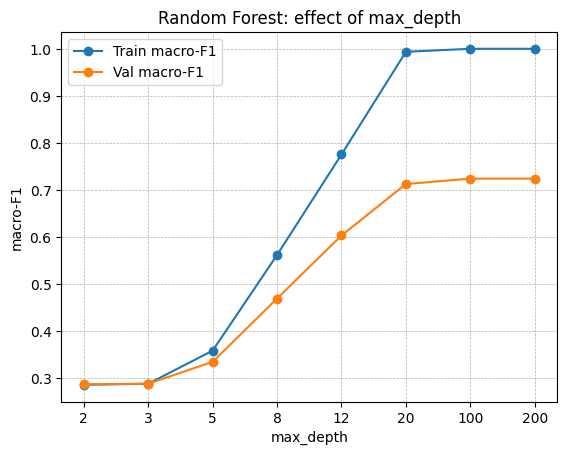

In [ ]:
#Q7.2
depth_grid = [2, 3, 5, 8, 12, 20, 100, 200, 300]
train_scores = []
val_scores = []

for d in depth_grid:
    rf_d = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1, max_depth=d
)
    rf_d.fit(X_train,y_train)

    y_tr_pred = rf_d.predict(X_train)
    y_va_pred = rf_d.predict(X_val)

    train_scores.append(f1_score(y_train,y_tr_pred,average='macro'))
    val_scores.append(f1_score(y_val,y_va_pred,average='macro'))

plt.figure()
x = list(range(len(depth_grid)))
plt.plot(x, train_scores, marker="o", label="Train macro-F1")
plt.plot(x, val_scores, marker="o", label="Val macro-F1")
plt.xticks(x, [str(d) for d in depth_grid])
plt.xlabel("max_depth")
plt.ylabel("macro-F1")
plt.title("Random Forest: effect of max_depth")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

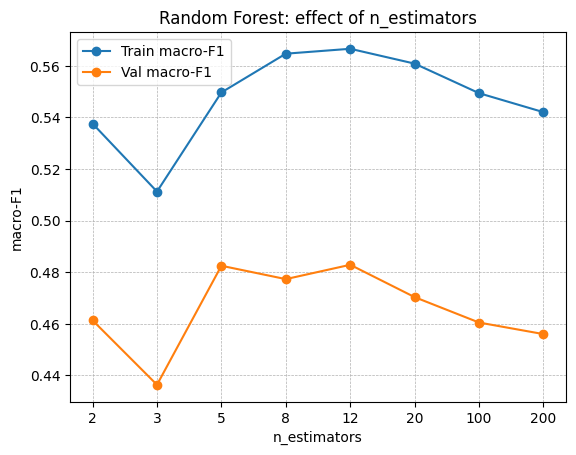

In [24]:
#Q7.3
#TODO
estimators_grid = [2, 3, 5, 8, 12, 20, 100, 200]
train_scores = []
val_scores = []

for d in estimators_grid:
    rf_d = RandomForestClassifier(n_estimators=d, random_state=42, n_jobs=-1, max_depth=8
)
    rf_d.fit(X_train,y_train)

    y_tr_pred = rf_d.predict(X_train)
    y_va_pred = rf_d.predict(X_val)

    train_scores.append(f1_score(y_train,y_tr_pred,average='macro'))
    val_scores.append(f1_score(y_val,y_va_pred,average='macro'))

plt.figure()
x = list(range(len(estimators_grid)))
plt.plot(x, train_scores, marker="o", label="Train macro-F1")
plt.plot(x, val_scores, marker="o", label="Val macro-F1")
plt.xticks(x, [str(d) for d in estimators_grid])
plt.xlabel("n_estimators")
plt.ylabel("macro-F1")
plt.title("Random Forest: effect of n_estimators")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

In [29]:
#Q7.4
best_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

# Train on combined train and validation sets
X_train_full = np.concatenate((X_train, X_val), axis=0)
y_train_full = np.concatenate((y_train, y_val), axis=0)

best_rf.fit(X_train_full, y_train_full)

print("\nFinal evaluation of best Random Forest on the test set:")
res_best_rf = eval_clf(best_rf, X_test, y_test)


Final evaluation of best Random Forest on the test set:
Performance
----------------
Macro F1: 76.44%
Overall accuracy: 85.51%

Per-class F1 (test) and training prevalence
-------------------------------------------
          Class name | F1 (test) |  Train %
-------------------------------------------
              Spruce |    85.21% |   36.46%
      Lodgepole pine |    87.91% |   48.76%
      Ponderosa pine |    84.25% |    6.16%
          Cottonwood |    79.55% |    0.47%
        Aspen poplar |    50.23% |    1.63%
         Douglas-fir |    65.49% |    2.99%
           Krummholz |    82.43% |    3.53%


## Q8 — Boosting (Gradient Boosted Decision Trees)

<font color='green'>
AT HOME QUESTION: SKIP DURING TP UNTIL YOU ARE FINISHED WITH THE GUIDED QUESTIONS
</font>

We now study **boosting**, which builds an ensemble *sequentially*: each new tree corrects the errors of the current model.
In practice, gradient boosting often outperforms random forests on tabular datasets, but it is more sensitive to hyperparameters.

We will use a modern implementation of gradient boosting trees: `HistGradientBoostingClassifier`.

### Q8.1 — Train a baseline boosted tree model
Train a gradient boosting model and evaluate it on train / test.

### Q8.2 — Effect of tree complexity (max_depth)
Study how `max_depth` affects performance:
- Train models for several values of `max_depth`
- Plot train and test macro-F1 as a function of `max_depth`
- Identify underfitting vs overfitting behaviour
- Report performance on test

### Q8.3 — Effect of the learning rate
Study how `learning_rate` affects performance:
- Train models for several values of `learning_rate`
- Plot train and test macro-F1 vs learning rate
- Explain why a smaller learning rate often requires more boosting iterations
- Report performance on test

### Q8.4 — Compare to random forests
Compare the boosted model and the random forest model:
- Which one performs best on test macro-F1?
- Which one is more sensitive to hyperparameters?
- Which one is faster to train in your environment?
- Report performance on test


In [ ]:
#Q8.1

gb = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=6,
    max_iter=200,
    random_state=42
)

gb.fit(X_train, y_train)
eval_clf(gb, X_test, y_test)

Performance
----------------
Macro F1: 66.74%
Overall accuracy: 78.61%

Per-class F1 (test) and training prevalence
-------------------------------------------
          Class name | F1 (test) |  Train %
-------------------------------------------
              Spruce |    77.30% |   36.46%
      Lodgepole pine |    81.93% |   48.76%
      Ponderosa pine |    78.62% |    6.16%
          Cottonwood |    53.06% |    0.47%
        Aspen poplar |    42.79% |    1.63%
         Douglas-fir |    59.82% |    2.99%
           Krummholz |    73.65% |    3.53%


0.6673845676647289

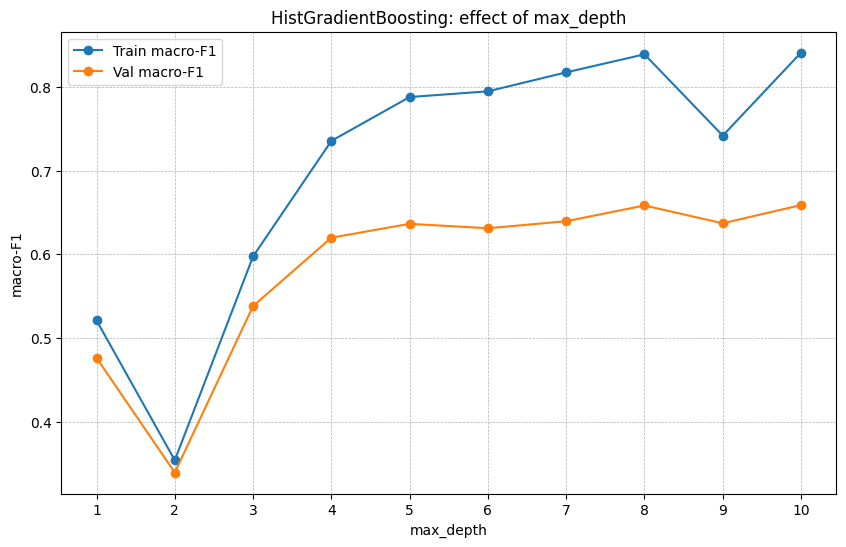


Best max_depth from validation: 10
Performance with best max_depth (10) on validation (train set fit):
Performance with best max_depth (10) on test (train set fit):
Performance
----------------
Macro F1: 66.61%
Overall accuracy: 79.12%

Per-class F1 (test) and training prevalence
-------------------------------------------
          Class name | F1 (test) |  Train %
-------------------------------------------
              Spruce |    78.22% |   36.46%
      Lodgepole pine |    82.17% |   48.76%
      Ponderosa pine |    78.45% |    6.16%
          Cottonwood |    37.40% |    0.47%
        Aspen poplar |    50.62% |    1.63%
         Douglas-fir |    61.78% |    2.99%
           Krummholz |    77.62% |    3.53%


0.6660852182664018

In [26]:
max_depth_grid = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
train_scores_depth = []
val_scores_depth = []

for md in max_depth_grid:
    gb_depth = HistGradientBoostingClassifier(
        learning_rate=0.1,  # Keep learning_rate fixed for this analysis
        max_depth=md,
        max_iter=200,
        random_state=42
    )
    gb_depth.fit(X_train, y_train)

    y_tr_pred = gb_depth.predict(X_train)
    y_va_pred = gb_depth.predict(X_val)

    train_scores_depth.append(f1_score(y_train, y_tr_pred, average='macro'))
    val_scores_depth.append(f1_score(y_val, y_va_pred, average='macro'))

plt.figure(figsize=(10, 6))
x = list(range(len(max_depth_grid)))
plt.plot(x, train_scores_depth, marker="o", label="Train macro-F1")
plt.plot(x, val_scores_depth, marker="o", label="Val macro-F1")
plt.xticks(x, [str(md) for md in max_depth_grid])
plt.xlabel("max_depth")
plt.ylabel("macro-F1")
plt.title("HistGradientBoosting: effect of max_depth")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

best_md_idx = np.argmax(val_scores_depth)
best_max_depth = max_depth_grid[best_md_idx]
print(f"\nBest max_depth from validation: {best_max_depth}")

best_gb_depth = HistGradientBoostingClassifier(
    learning_rate=0.1,
    max_depth=best_max_depth,
    max_iter=200,
    random_state=42
)
best_gb_depth.fit(X_train, y_train)

print(f"Performance with best max_depth ({best_max_depth}) on validation (train set fit):")
eval_clf(best_gb_depth, X_val, y_val, silent=True)
print(f"Performance with best max_depth ({best_max_depth}) on test (train set fit):")
eval_clf(best_gb_depth, X_test, y_test)

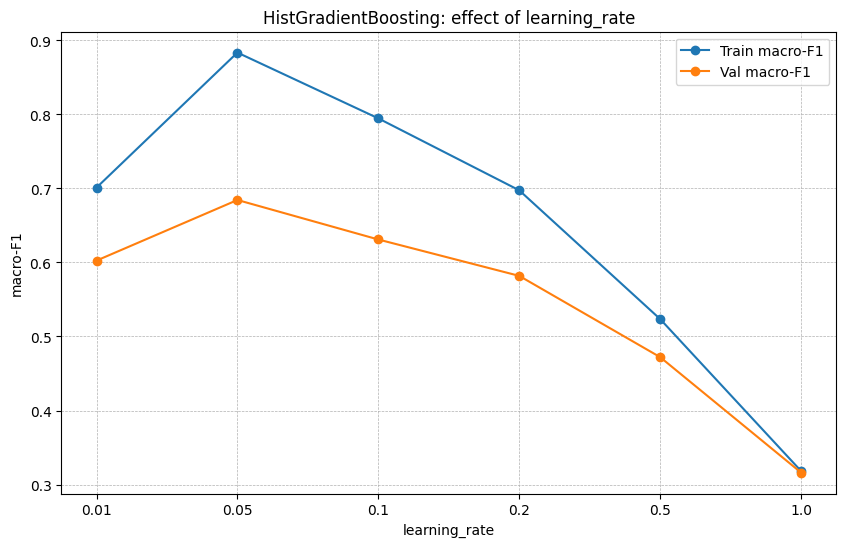

In [27]:
#Q8.3
learning_rate_grid = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0]
train_scores_lr = []
val_scores_lr = []

for lr in learning_rate_grid:
    gb_lr = HistGradientBoostingClassifier(
        learning_rate=lr,
        max_depth=6, # Keep max_depth fixed, e.g., from Q8.1 or based on Q8.2 results
        max_iter=200, # Keep max_iter fixed
        random_state=42
    )
    gb_lr.fit(X_train, y_train)

    y_tr_pred = gb_lr.predict(X_train)
    y_va_pred = gb_lr.predict(X_val)

    train_scores_lr.append(f1_score(y_train, y_tr_pred, average='macro'))
    val_scores_lr.append(f1_score(y_val, y_va_pred, average='macro'))

plt.figure(figsize=(10, 6))
x = list(range(len(learning_rate_grid)))
plt.plot(x, train_scores_lr, marker="o", label="Train macro-F1")
plt.plot(x, val_scores_lr, marker="o", label="Val macro-F1")
plt.xticks(x, [str(lr) for lr in learning_rate_grid])
plt.xlabel("learning_rate")
plt.ylabel("macro-F1")
plt.title("HistGradientBoosting: effect of learning_rate")
plt.grid(True, linestyle="--", linewidth=0.5)
plt.legend()
plt.show()

In [30]:
#Q8.4

#
best_gb = HistGradientBoostingClassifier(
    learning_rate=0.05,
    max_depth=8,
    max_iter=200,
    random_state=42
)


X_train_full = np.concatenate((X_train, X_val), axis=0)
y_train_full = np.concatenate((y_train, y_val), axis=0)

best_gb.fit(X_train_full, y_train_full)

print("\nFinal evaluation of best HistGradientBoostingClassifier on the test set:")
res_best_gb = eval_clf(best_gb, X_test, y_test)

print("\n--- Comparison ---")
print(f"Random Forest (best F1): {res_best_rf:.4f}")
print(f"Gradient Boosting (best F1): {res_best_gb:.4f}")




Final evaluation of best HistGradientBoostingClassifier on the test set:
Performance
----------------
Macro F1: 75.69%
Overall accuracy: 81.99%

Per-class F1 (test) and training prevalence
-------------------------------------------
          Class name | F1 (test) |  Train %
-------------------------------------------
              Spruce |    80.37% |   36.46%
      Lodgepole pine |    84.46% |   48.76%
      Ponderosa pine |    83.41% |    6.16%
          Cottonwood |    78.57% |    0.47%
        Aspen poplar |    52.99% |    1.63%
         Douglas-fir |    68.01% |    2.99%
           Krummholz |    81.99% |    3.53%

--- Comparison ---
Random Forest (best F1): 0.7644
Gradient Boosting (best F1): 0.7569


### Dataset courtesy of:

Remote Sensing and GIS Program

Department of Forest Sciences

College of Natural Resources

Colorado State University

Fort Collins, CO 80523